# Обучение классификатора покрытий стен
Используем названия папок как предварительные метки. Ручная проверка не требуется. Исходные фото не изменяются. SegFormer и MobileNet работают локально; при первом запуске скачиваются готовые веса.

Запускайте ячейки по порядку. Результат теста предварительный: метки папок не проверены. Одинаковые файлы группируются по содержимому; разные снимки одного помещения автоматически не выявляются.


In [8]:
%pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 9.9 MB/s  0:00:00m 9.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 10.5 MB/s  0:00:01 10.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn]0m 5/6 [scikit-learn]]
Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import json, hashlib, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

DATA_DIR = Path('/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/data/dataset/walls')
OUT = Path('/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/wall_training')
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)


Device: mps


In [15]:
# Только локальная проверка одинакового содержимого; платные API не используются.
extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}
rows = []
for folder in sorted(DATA_DIR.iterdir()):
    if not folder.is_dir() or folder.name in {'duplicates', 'uncertain'}:
        continue
    for path in sorted(folder.rglob('*')):
        if path.is_file() and path.suffix.lower() in extensions and 'duplicates' not in path.relative_to(DATA_DIR).parts:
            digest = hashlib.sha256(path.read_bytes()).hexdigest()
            rows.append({'path': str(path), 'label': folder.name, 'digest': digest})
raw = pd.DataFrame(rows)
assert len(raw), 'Фото не найдены'
conflicts = raw.groupby('digest')['label'].nunique()
conflict_ids = set(conflicts[conflicts > 1].index)
raw[raw.digest.isin(conflict_ids)].to_csv(OUT / 'conflicting_labels.csv', index=False)
clean = raw[~raw.digest.isin(conflict_ids)].drop_duplicates('digest').copy()
print('Всего:', len(raw), 'После исключения точных повторов и конфликтов:', len(clean))
display(clean.groupby('label').size().rename('photos'))
assert clean.groupby('label').size().min() >= 10, 'В одном из классов недостаточно фото для трёх выборок'
train, rest = train_test_split(clean, test_size=0.30, stratify=clean.label, random_state=SEED)
val, test = train_test_split(rest, test_size=0.50, stratify=rest.label, random_state=SEED)
manifest = pd.concat([part.assign(split=name) for name, part in [('train', train), ('val', val), ('test', test)]], ignore_index=True)
manifest.to_csv(OUT / 'split_manifest.csv', index=False)
classes = sorted(clean.label.unique())
print('Train / val / test:', len(train), len(val), len(test))


Всего: 554 После исключения точных повторов и конфликтов: 554


label
bare_concrete                  68
bare_masonry                   65
decorative_stone_or_brick      62
exposed_drywall                44
painted                        53
textured_decorative_finish     45
tile                           74
unfinished_plaster_or_putty    34
wall_paneling                  67
wallpaper                      42
Name: photos, dtype: int64

Train / val / test: 387 83 84


## Подготовка областей стен
SegFormer выделяет стену. Обрезаем её границы и заменяем остальные пиксели серым. При слишком маленькой маске исключаем снимок и сохраняем отчёт. Эту же подготовку нужно использовать при дальнейшем применении модели.


In [16]:
processor = AutoImageProcessor.from_pretrained('nvidia/segformer-b0-finetuned-ade-512-512')
segmenter = SegformerForSemanticSegmentation.from_pretrained('nvidia/segformer-b0-finetuned-ade-512-512').to(device).eval()
wall_id = next(int(k) for k, v in segmenter.config.id2label.items() if v == 'wall')
CACHE = OUT / 'wall_crops'
CACHE.mkdir(exist_ok=True)

@torch.no_grad()
def wall_crop(path):
    with Image.open(path) as source:
        image = ImageOps.exif_transpose(source).convert('RGB')
        image.thumbnail((1024, 1024))
    inputs = processor(images=image, return_tensors='pt').to(device)
    logits = segmenter(**inputs).logits
    mask = F.interpolate(logits, size=(image.height, image.width), mode='bilinear', align_corners=False).argmax(1)[0].cpu().numpy() == wall_id
    if mask.mean() < 0.05:
        return None
    ys, xs = np.where(mask)
    pixels = np.asarray(image).copy()
    pixels[~mask] = [124, 116, 104]
    return Image.fromarray(pixels).crop((int(xs.min()), int(ys.min()), int(xs.max())+1, int(ys.max())+1))

prepared, skipped = [], []
for index, row in enumerate(manifest.to_dict('records')):
    crop_path = CACHE / (row['digest'] + '.png')
    try:
        if not crop_path.exists():
            crop = wall_crop(row['path'])
            if crop is None:
                skipped.append({**row, 'reason': 'wall mask under 5%'})
                continue
            crop.save(crop_path)
        prepared.append({**row, 'crop_path': str(crop_path)})
    except (OSError, ValueError) as error:
        skipped.append({**row, 'reason': str(error)})
    if (index + 1) % 25 == 0:
        print(index + 1, '/', len(manifest))
prepared = pd.DataFrame(prepared)
pd.DataFrame(skipped).to_csv(OUT / 'skipped_photos.csv', index=False)
prepared.to_csv(OUT / 'prepared_manifest.csv', index=False)
assert len(prepared), 'Нет пригодных областей стен'
display(pd.crosstab(prepared.label, prepared.split))
for split in ['train', 'val', 'test']:
    assert set(prepared[prepared.split == split].label) == set(classes), f'После сегментации в {split} пропал класс'
del segmenter
if device.type == 'mps': torch.mps.empty_cache()


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

25 / 554
75 / 554
100 / 554
125 / 554
175 / 554
200 / 554
275 / 554
325 / 554
350 / 554
375 / 554
400 / 554
425 / 554
450 / 554
475 / 554
500 / 554
550 / 554


split,test,train,val
label,,,
bare_concrete,9,42,10
bare_masonry,10,37,10
decorative_stone_or_brick,9,40,8
exposed_drywall,7,28,5
painted,4,34,8
textured_decorative_finish,7,17,4
tile,11,51,11
unfinished_plaster_or_putty,3,20,5
wall_paneling,10,44,10


In [10]:
normalize = transforms.Normalize([.485, .456, .406], [.229, .224, .225])
train_transform = transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=.1, contrast=.1), transforms.ToTensor(), normalize])
eval_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), normalize])
class WallDataset(Dataset):
    def __init__(self, frame, transform):
        self.rows = frame.to_dict('records'); self.transform = transform
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        with Image.open(row['crop_path']) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, classes.index(row['label'])

frames = {s: prepared[prepared.split == s].reset_index(drop=True) for s in ['train', 'val', 'test']}
loaders = {s: DataLoader(WallDataset(frame, train_transform if s == 'train' else eval_transform), batch_size=16, shuffle=s=='train', num_workers=0) for s, frame in frames.items()}
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
for parameter in model.features.parameters(): parameter.requires_grad = False
model.classifier[-1] = torch.nn.Linear(model.classifier[-1].in_features, len(classes))
model.to(device)
criterion = torch.nn.CrossEntropyLoss()


In [17]:
def epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training: model.features.eval()  # Сохраняем статистики замороженной базы.
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            scores = model(images); loss = criterion(scores, labels)
            if training: loss.backward(); optimizer.step()
        total_loss += loss.item()*len(labels)
        correct += (scores.argmax(1)==labels).sum().item(); total += len(labels)
    return total_loss/total, correct/total

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
best_loss = float('inf'); history = []
for n in range(15):
    train_loss, train_acc = epoch(loaders['train'], optimizer)
    val_loss, val_acc = epoch(loaders['val'])
    history.append(dict(epoch=n+1, train_loss=train_loss, val_loss=val_loss, train_acc=train_acc, val_acc=val_acc))
    print(f'{n+1}/15 train={train_acc:.3f} val={val_acc:.3f} val_loss={val_loss:.3f}')
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save({'state_dict': {k:v.detach().cpu() for k,v in model.state_dict().items()}, 'classes':classes, 'architecture':'mobilenet_v3_small', 'input_size':224, 'segformer':'nvidia/segformer-b0-finetuned-ade-512-512', 'minimum_wall_fraction':.05}, OUT/'wall_classifier_best.pt')
pd.DataFrame(history).to_csv(OUT/'history.csv', index=False)


1/15 train=0.842 val=0.493 val_loss=1.417
2/15 train=0.934 val=0.520 val_loss=1.308
3/15 train=0.973 val=0.480 val_loss=1.465
4/15 train=0.991 val=0.440 val_loss=1.583
5/15 train=0.994 val=0.507 val_loss=1.493
6/15 train=1.000 val=0.507 val_loss=1.526
7/15 train=1.000 val=0.520 val_loss=1.704
8/15 train=1.000 val=0.493 val_loss=1.658
9/15 train=1.000 val=0.480 val_loss=1.672
10/15 train=1.000 val=0.533 val_loss=1.813
11/15 train=1.000 val=0.467 val_loss=1.804
12/15 train=1.000 val=0.493 val_loss=1.774
13/15 train=1.000 val=0.507 val_loss=1.764
14/15 train=1.000 val=0.507 val_loss=1.809
15/15 train=1.000 val=0.507 val_loss=1.863


## Этап 2 — Дообучение последних слоёв MobileNetV3
Начинаем с лучшей модели первого этапа. Исходные веса первого этапа не перезаписываются. Выбор модели и ранняя остановка используют только validation. После этого запускайте оценку ниже; тест уже использовался, поэтому повторная оценка остаётся предварительной.


In [18]:
# Запускайте после первого обучения. Повторять 15 эпох первого этапа не нужно.
checkpoint = torch.load(OUT / 'wall_classifier_best.pt', map_location='cpu', weights_only=True)
assert checkpoint['classes'] == classes, 'Список классов изменился'
model.load_state_dict(checkpoint['state_dict'])
model.to(device)

# Размораживаем только последние три блока основы.
for parameter in model.features.parameters():
    parameter.requires_grad = False
for block in list(model.features.children())[-3:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

# Определение отдельно, чтобы не запускать снова первый цикл обучения.
def fine_tune_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    # Фиксируем BatchNorm на маленьком датасете. Градиенты размороженных весов работают.
    model.features.eval()
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            scores = model(images)
            loss = criterion(scores, labels)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (scores.argmax(1) == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total

optimizer_ft = torch.optim.Adam([
    {'params': [p for p in model.features.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)
baseline_loss, baseline_accuracy = fine_tune_epoch(loaders['val'])
best_ft_loss = baseline_loss
ft_path = OUT / 'wall_classifier_finetuned_best.pt'
# Сохраняем исходную модель как запасной вариант, если fine-tuning не улучшит валидацию.
torch.save({**checkpoint, 'stage': 'head_baseline', 'val_loss': baseline_loss}, ft_path)
print(f'До fine-tuning: val={baseline_accuracy:.3f} val_loss={baseline_loss:.3f}')
ft_history = []
stale_epochs = 0
for n in range(10):
    train_loss, train_acc = fine_tune_epoch(loaders['train'], optimizer_ft)
    val_loss, val_acc = fine_tune_epoch(loaders['val'])
    ft_history.append(dict(epoch=n+1, train_loss=train_loss, train_acc=train_acc, val_loss=val_loss, val_acc=val_acc))
    print(f'FT {n+1}/10 train={train_acc:.3f} val={val_acc:.3f} val_loss={val_loss:.3f}')
    if val_loss < best_ft_loss - 1e-4:
        best_ft_loss = val_loss
        stale_epochs = 0
        torch.save({**checkpoint, 'state_dict': {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 'stage': 'fine_tuned', 'val_loss': val_loss, 'epoch': n+1}, ft_path)
    else:
        stale_epochs += 1
    if stale_epochs >= 3:
        print('Остановка: три эпохи без улучшения val_loss')
        break
pd.DataFrame(ft_history).to_csv(OUT / 'finetune_history.csv', index=False)
chosen = torch.load(ft_path, map_location='cpu', weights_only=True)
model.load_state_dict(chosen['state_dict'])
print('Выбранная модель:', chosen['stage'], 'val_loss:', chosen['val_loss'])


До fine-tuning: val=0.520 val_loss=1.308
FT 1/10 train=0.976 val=0.533 val_loss=1.304
FT 2/10 train=0.982 val=0.533 val_loss=1.349
FT 3/10 train=0.982 val=0.533 val_loss=1.338
FT 4/10 train=0.994 val=0.533 val_loss=1.368
Остановка: три эпохи без улучшения val_loss
Выбранная модель: fine_tuned val_loss: 1.3041818730036419


                             precision    recall  f1-score   support

              bare_concrete       0.50      0.78      0.61         9
               bare_masonry       0.60      0.60      0.60        10
  decorative_stone_or_brick       0.55      0.67      0.60         9
            exposed_drywall       0.67      0.29      0.40         7
                    painted       0.29      0.50      0.36         4
 textured_decorative_finish       0.50      0.14      0.22         7
                       tile       0.73      0.73      0.73        11
unfinished_plaster_or_putty       0.67      0.67      0.67         3
              wall_paneling       0.67      0.60      0.63        10
                  wallpaper       0.25      0.25      0.25         4

                   accuracy                           0.55        74
                  macro avg       0.54      0.52      0.51        74
               weighted avg       0.57      0.55      0.54        74

Результаты: /Users/himynameisar

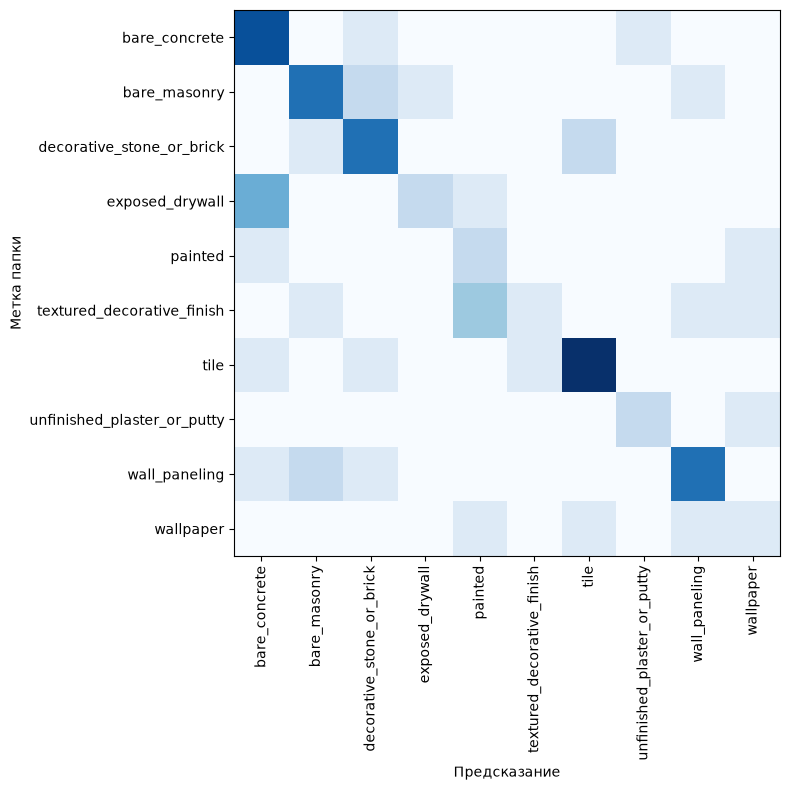

In [19]:
checkpoint = torch.load(OUT/'wall_classifier_finetuned_best.pt', map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint['state_dict']); model.eval()
truth, predictions = [], []
with torch.no_grad():
    for images, labels in loaders['test']:
        predictions.extend(model(images.to(device)).argmax(1).cpu().tolist())
        truth.extend(labels.tolist())
print(classification_report(truth, predictions, labels=list(range(len(classes))), target_names=classes, zero_division=0))
matrix = confusion_matrix(truth, predictions, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(10,8)); ax.imshow(matrix, cmap='Blues')
ax.set_xticks(range(len(classes)), classes, rotation=90); ax.set_yticks(range(len(classes)), classes)
ax.set_xlabel('Предсказание'); ax.set_ylabel('Метка папки'); plt.tight_layout()
results = frames['test'].copy()
results['predicted_label'] = [classes[i] for i in predictions]
results['correct'] = results.label == results.predicted_label
results.to_csv(OUT/'test_predictions_finetuned.csv', index=False)
print('Результаты:', OUT)


## Этап 3 — Целые фото: текущая и усиленная аугментация
Запускайте новые ячейки ниже. Повторять сегментацию и предыдущие обучения не нужно; этот раздел сам загружает сохранённую выборку.

Для сравнения используем ровно те фото и разделение из `prepared_manifest.csv`, что участвовали в эксперименте с масками. Каждая модель начинает с одинаковых весов ImageNet и новой головы. Обучаем только голову — сравниваем с первым этапом, а не смешиваем эффект входных данных с fine-tuning.

Валидация и тест без случайных преобразований. Тест уже использовался, поэтому сравнение предварительное. Усиленная аугментация не гарантирует улучшение.


In [1]:
from pathlib import Path
import random, json
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt

PROJECT = Path('/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV')
EXPERIMENT_OUT = PROJECT / 'outputs/wall_training/full_photo_experiments'
EXPERIMENT_OUT.mkdir(parents=True, exist_ok=True)
comparison_manifest = pd.read_csv(PROJECT / 'outputs/wall_training/prepared_manifest.csv')
comparison_classes = sorted(comparison_manifest.label.unique().tolist())
experiment_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
for split in ['train', 'val', 'test']:
    part = comparison_manifest[comparison_manifest.split == split]
    assert len(part) and set(part.label) == set(comparison_classes), f'Неполная выборка {split}'
assert comparison_manifest.digest.is_unique, 'Повторяющиеся фото в выборке'
assert all(Path(p).is_file() for p in comparison_manifest.path), 'Исходные фото не найдены'
display(pd.crosstab(comparison_manifest.label, comparison_manifest.split))

image_normalize = transforms.Normalize([.485, .456, .406], [.229, .224, .225])
full_eval_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), image_normalize])
full_baseline_transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.1, contrast=.1),
    transforms.ToTensor(), image_normalize,
])
full_augmented_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomAffine(degrees=7, translate=(.04,.04), scale=(.9,1.1), fill=(124,116,104)),
    transforms.RandomCrop(224), transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.2, saturation=.1),
    transforms.ToTensor(), image_normalize,
])

class FullPhotoDataset(Dataset):
    def __init__(self, frame, transform):
        self.rows = frame.to_dict('records')
        self.transform = transform
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        with Image.open(row['path']) as source:
            image = ImageOps.exif_transpose(source).convert('RGB')
            tensor = self.transform(image)
        return tensor, comparison_classes.index(row['label'])


split,test,train,val
label,,,
bare_concrete,9,42,10
bare_masonry,10,37,10
decorative_stone_or_brick,9,40,8
exposed_drywall,7,28,5
painted,4,34,8
textured_decorative_finish,7,17,4
tile,11,51,11
unfinished_plaster_or_putty,3,20,5
wall_paneling,10,44,10


In [2]:
def train_full_photo_experiment(name, training_transform):
    random.seed(42); np.random.seed(42); torch.manual_seed(42)
    exp_dir = EXPERIMENT_OUT / name
    exp_dir.mkdir(exist_ok=True)
    parts = {s: comparison_manifest[comparison_manifest.split == s].reset_index(drop=True) for s in ['train','val','test']}
    exp_loaders = {
        s: DataLoader(FullPhotoDataset(frame, training_transform if s == 'train' else full_eval_transform),
                      batch_size=16, shuffle=s == 'train', num_workers=0,
                      generator=torch.Generator().manual_seed(42))
        for s, frame in parts.items()
    }
    net = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    for parameter in net.features.parameters(): parameter.requires_grad = False
    net.classifier[-1] = torch.nn.Linear(net.classifier[-1].in_features, len(comparison_classes))
    net.to(experiment_device)
    loss_function = torch.nn.CrossEntropyLoss()
    opt = torch.optim.Adam(net.classifier.parameters(), lr=1e-3)

    def run(loader, training=False):
        net.train(training); net.features.eval()
        total_loss = correct = count = 0
        for images, labels in loader:
            images, labels = images.to(experiment_device), labels.to(experiment_device)
            if training: opt.zero_grad()
            with torch.set_grad_enabled(training):
                scores = net(images); loss = loss_function(scores, labels)
                if training: loss.backward(); opt.step()
            total_loss += loss.item()*len(labels)
            correct += (scores.argmax(1) == labels).sum().item(); count += len(labels)
        return total_loss/count, correct/count

    best_loss = float('inf'); history = []
    for epoch_number in range(15):
        tr_loss, tr_acc = run(exp_loaders['train'], True)
        va_loss, va_acc = run(exp_loaders['val'])
        history.append(dict(epoch=epoch_number+1, train_loss=tr_loss, train_acc=tr_acc, val_loss=va_loss, val_acc=va_acc))
        print(f'{name} {epoch_number+1}/15 train={tr_acc:.3f} val={va_acc:.3f} val_loss={va_loss:.3f}')
        if va_loss < best_loss:
            best_loss = va_loss
            torch.save(dict(state_dict={k:v.detach().cpu().clone() for k,v in net.state_dict().items()}, classes=comparison_classes,
                            architecture='mobilenet_v3_small', input='full_photo', experiment=name, epoch=epoch_number+1, val_loss=va_loss), exp_dir/'best.pt')
    pd.DataFrame(history).to_csv(exp_dir/'history.csv', index=False)
    best = torch.load(exp_dir/'best.pt', map_location='cpu', weights_only=True)
    net.load_state_dict(best['state_dict']); net.eval()
    truth, predicted = [], []
    with torch.no_grad():
        for images, labels in exp_loaders['test']:
            predicted.extend(net(images.to(experiment_device)).argmax(1).cpu().tolist())
            truth.extend(labels.tolist())
    report = classification_report(truth, predicted, labels=list(range(len(comparison_classes))), target_names=comparison_classes, zero_division=0)
    print(name, '\n', report)
    (exp_dir/'classification_report.txt').write_text(report)
    predictions = parts['test'].copy()
    predictions['predicted_label'] = [comparison_classes[i] for i in predicted]
    predictions.to_csv(exp_dir/'test_predictions.csv', index=False)
    matrix = confusion_matrix(truth, predicted, labels=list(range(len(comparison_classes))))
    fig, ax = plt.subplots(figsize=(10,8)); ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(comparison_classes)), comparison_classes, rotation=90)
    ax.set_yticks(range(len(comparison_classes)), comparison_classes)
    ax.set_xlabel('Предсказание'); ax.set_ylabel('Метка папки'); ax.set_title(name)
    fig.tight_layout(); fig.savefig(exp_dir/'confusion_matrix.png'); plt.show()
    summary = dict(experiment=name, test_accuracy=accuracy_score(truth,predicted), macro_f1=f1_score(truth,predicted,labels=list(range(len(comparison_classes))),average='macro',zero_division=0), best_val_loss=best_loss, best_epoch=best['epoch'], test_size=len(truth))
    (exp_dir/'summary.json').write_text(json.dumps(summary, indent=2))
    del net
    if experiment_device.type == 'mps': torch.mps.empty_cache()
    return summary


### Эксперимент A — целые фото, прежняя аугментация


full_baseline 1/15 train=0.349 val=0.613 val_loss=1.204
full_baseline 2/15 train=0.740 val=0.680 val_loss=0.935
full_baseline 3/15 train=0.824 val=0.707 val_loss=0.873
full_baseline 4/15 train=0.907 val=0.707 val_loss=0.851
full_baseline 5/15 train=0.934 val=0.720 val_loss=0.892
full_baseline 6/15 train=0.979 val=0.653 val_loss=0.954
full_baseline 7/15 train=0.970 val=0.627 val_loss=0.986
full_baseline 8/15 train=0.991 val=0.680 val_loss=0.979
full_baseline 9/15 train=0.994 val=0.640 val_loss=1.054
full_baseline 10/15 train=0.997 val=0.693 val_loss=0.991
full_baseline 11/15 train=1.000 val=0.667 val_loss=1.052
full_baseline 12/15 train=0.997 val=0.707 val_loss=1.001
full_baseline 13/15 train=1.000 val=0.667 val_loss=1.089
full_baseline 14/15 train=1.000 val=0.667 val_loss=1.089
full_baseline 15/15 train=1.000 val=0.680 val_loss=1.145
full_baseline 
                              precision    recall  f1-score   support

              bare_concrete       0.62      0.89      0.73         9

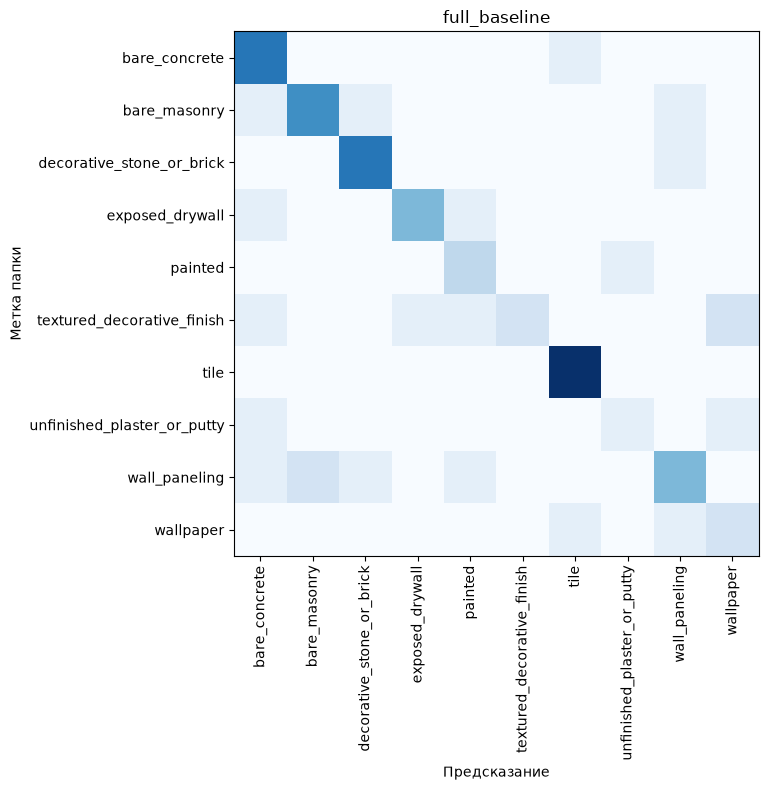

In [22]:
baseline_full_summary = train_full_photo_experiment('full_baseline', full_baseline_transform)


### Эксперимент B — целые фото, усиленная аугментация


full_augmented 1/15 train=0.346 val=0.573 val_loss=1.241
full_augmented 2/15 train=0.684 val=0.693 val_loss=0.955
full_augmented 3/15 train=0.755 val=0.720 val_loss=0.875
full_augmented 4/15 train=0.833 val=0.720 val_loss=0.845
full_augmented 5/15 train=0.893 val=0.707 val_loss=0.879
full_augmented 6/15 train=0.928 val=0.720 val_loss=0.911
full_augmented 7/15 train=0.943 val=0.600 val_loss=1.068
full_augmented 8/15 train=0.943 val=0.707 val_loss=0.946
full_augmented 9/15 train=0.958 val=0.667 val_loss=1.058
full_augmented 10/15 train=0.970 val=0.707 val_loss=0.994
full_augmented 11/15 train=0.949 val=0.653 val_loss=1.127
full_augmented 12/15 train=0.982 val=0.680 val_loss=1.086
full_augmented 13/15 train=0.982 val=0.667 val_loss=1.087
full_augmented 14/15 train=0.994 val=0.680 val_loss=1.064
full_augmented 15/15 train=0.991 val=0.627 val_loss=1.191
full_augmented 
                              precision    recall  f1-score   support

              bare_concrete       0.64      1.00    

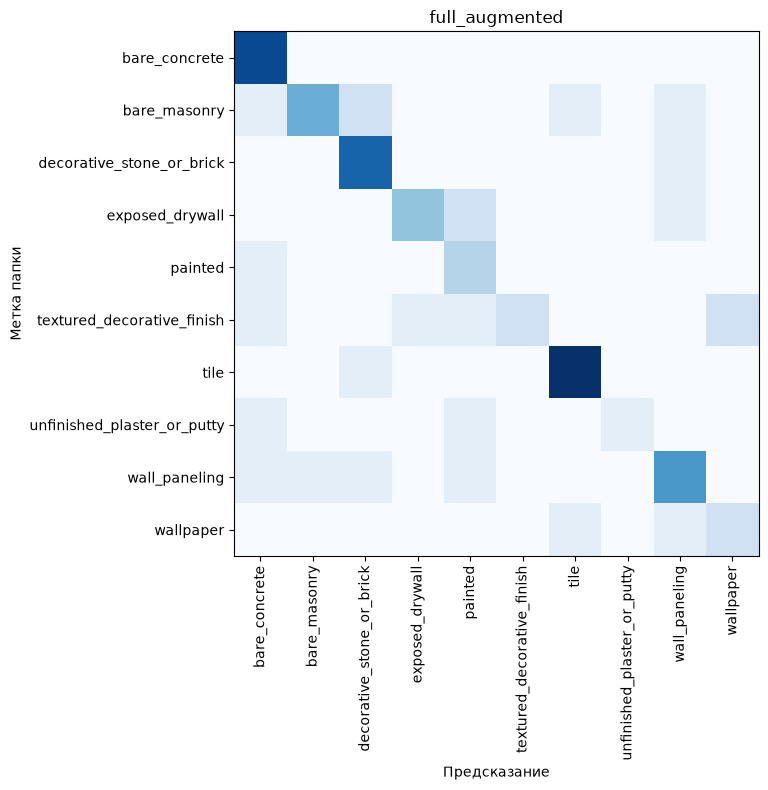

In [23]:
augmented_full_summary = train_full_photo_experiment('full_augmented', full_augmented_transform)


In [24]:
summaries = []
for name in ['full_baseline', 'full_augmented']:
    path = EXPERIMENT_OUT / name / 'summary.json'
    if path.exists(): summaries.append(json.loads(path.read_text()))
display(pd.DataFrame(summaries))
print('Для прежнего эксперимента с масками: 42/74 = 56.8% accuracy.')
print('Сравниваем accuracy вместе с macro F1. Рост на целых комнатах может быть связан с интерьером, а не материалом.')
print('Отчёты:', EXPERIMENT_OUT)


,experiment,test_accuracy,macro_f1,best_val_loss,best_epoch,test_size
0,full_baseline,0.702703,0.643656,0.850689,4,74
1,full_augmented,0.675676,0.625019,0.845133,4,74


Для прежнего эксперимента с масками: 42/74 = 56.8% accuracy.
Сравниваем accuracy вместе с macro F1. Рост на целых комнатах может быть связан с интерьером, а не материалом.
Отчёты: /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/wall_training/full_photo_experiments


## Этап 4 — Дообучение full_baseline на целых фото
Запустите две ячейки ниже. Если kernel перезапущен, сначала выполните ячейку подготовки этапа 3 с определением FullPhotoDataset. Повторять предыдущие обучения не нужно.
Начинаем с лучшей full_baseline, сохраняем прежнюю аугментацию и размораживаем последние три блока. Выбор по validation; исходная модель остаётся запасным вариантом. Тест уже многократно использовался, его оценка предварительная.


In [25]:
# Требуется ячейка подготовки из этапа 3 (FullPhotoDataset и transforms).
random.seed(42); np.random.seed(42); torch.manual_seed(42)
base_dir = EXPERIMENT_OUT / 'full_baseline'
ft_dir = EXPERIMENT_OUT / 'full_baseline_finetuned'
ft_dir.mkdir(exist_ok=True)
base_checkpoint = torch.load(base_dir / 'best.pt', map_location='cpu', weights_only=True)
assert base_checkpoint['classes'] == comparison_classes, 'Изменился список классов'
ft_parts = {s: comparison_manifest[comparison_manifest.split == s].reset_index(drop=True) for s in ['train','val','test']}
ft_loaders = {s: DataLoader(FullPhotoDataset(frame, full_baseline_transform if s == 'train' else full_eval_transform), batch_size=16, shuffle=s=='train', num_workers=0, generator=torch.Generator().manual_seed(42)) for s,frame in ft_parts.items()}
full_ft_net = models.mobilenet_v3_small(weights=None)
full_ft_net.classifier[-1] = torch.nn.Linear(full_ft_net.classifier[-1].in_features, len(comparison_classes))
full_ft_net.load_state_dict(base_checkpoint['state_dict'])
full_ft_net.to(experiment_device)
for parameter in full_ft_net.features.parameters(): parameter.requires_grad = False
for block in list(full_ft_net.features.children())[-3:]:
    for parameter in block.parameters(): parameter.requires_grad = True
ft_optimizer = torch.optim.Adam([
    {'params':[p for p in full_ft_net.features.parameters() if p.requires_grad], 'lr':1e-5},
    {'params':full_ft_net.classifier.parameters(), 'lr':1e-4},
], weight_decay=1e-4)
ft_loss_function = torch.nn.CrossEntropyLoss()

def full_ft_epoch(loader, training=False):
    full_ft_net.train(training)
    full_ft_net.features.eval()  # Фиксируем BatchNorm, сохраняя градиенты размороженных весов.
    loss_sum = correct = count = 0
    for images, labels in loader:
        images, labels = images.to(experiment_device), labels.to(experiment_device)
        if training: ft_optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            scores = full_ft_net(images); loss = ft_loss_function(scores, labels)
            if training: loss.backward(); ft_optimizer.step()
        loss_sum += loss.item()*len(labels)
        correct += (scores.argmax(1)==labels).sum().item(); count += len(labels)
    return loss_sum/count, correct/count

initial_loss, initial_acc = full_ft_epoch(ft_loaders['val'])
print(f'Исходная модель: val={initial_acc:.3f} val_loss={initial_loss:.3f}')
best_full_ft_loss = initial_loss
best_full_ft_path = ft_dir / 'best.pt'
torch.save({**base_checkpoint,'experiment':'full_baseline_finetuned','stage':'baseline_retained','val_loss':initial_loss}, best_full_ft_path)
full_ft_history = []; stale = 0
for n in range(10):
    tr_loss,tr_acc = full_ft_epoch(ft_loaders['train'],True)
    va_loss,va_acc = full_ft_epoch(ft_loaders['val'])
    full_ft_history.append(dict(epoch=n+1,train_loss=tr_loss,train_acc=tr_acc,val_loss=va_loss,val_acc=va_acc))
    print(f'Full FT {n+1}/10 train={tr_acc:.3f} val={va_acc:.3f} val_loss={va_loss:.3f}')
    if va_loss < best_full_ft_loss - 1e-4:
        best_full_ft_loss = va_loss; stale = 0
        torch.save({**base_checkpoint,'state_dict':{k:v.detach().cpu().clone() for k,v in full_ft_net.state_dict().items()},'experiment':'full_baseline_finetuned','stage':'fine_tuned','epoch':n+1,'val_loss':va_loss}, best_full_ft_path)
    else: stale += 1
    if stale >= 3:
        print('Остановка: три эпохи без улучшения val_loss'); break
pd.DataFrame(full_ft_history).to_csv(ft_dir/'history.csv',index=False)
full_chosen = torch.load(best_full_ft_path,map_location='cpu',weights_only=True)
full_ft_net.load_state_dict(full_chosen['state_dict'])
print('Выбрано:',full_chosen['stage'],'val_loss:',full_chosen['val_loss'])


Исходная модель: val=0.707 val_loss=0.851
Full FT 1/10 train=0.970 val=0.707 val_loss=0.863
Full FT 2/10 train=0.979 val=0.707 val_loss=0.884
Full FT 3/10 train=0.991 val=0.720 val_loss=0.878
Остановка: три эпохи без улучшения val_loss
Выбрано: baseline_retained val_loss: 0.8506889001528422


                             precision    recall  f1-score   support

              bare_concrete       0.62      0.89      0.73         9
               bare_masonry       0.78      0.70      0.74        10
  decorative_stone_or_brick       0.80      0.89      0.84         9
            exposed_drywall       0.83      0.71      0.77         7
                    painted       0.50      0.75      0.60         4
 textured_decorative_finish       1.00      0.29      0.44         7
                       tile       0.85      1.00      0.92        11
unfinished_plaster_or_putty       0.50      0.33      0.40         3
              wall_paneling       0.62      0.50      0.56        10
                  wallpaper       0.40      0.50      0.44         4

                   accuracy                           0.70        74
                  macro avg       0.69      0.66      0.64        74
               weighted avg       0.73      0.70      0.69        74



,experiment,test_accuracy,macro_f1,best_val_loss,best_epoch,test_size,stage
0,full_baseline,0.702703,0.643656,0.850689,4,74,NaN
1,full_baseline_finetuned,0.702703,0.643656,0.850689,4,74,baseline_retained


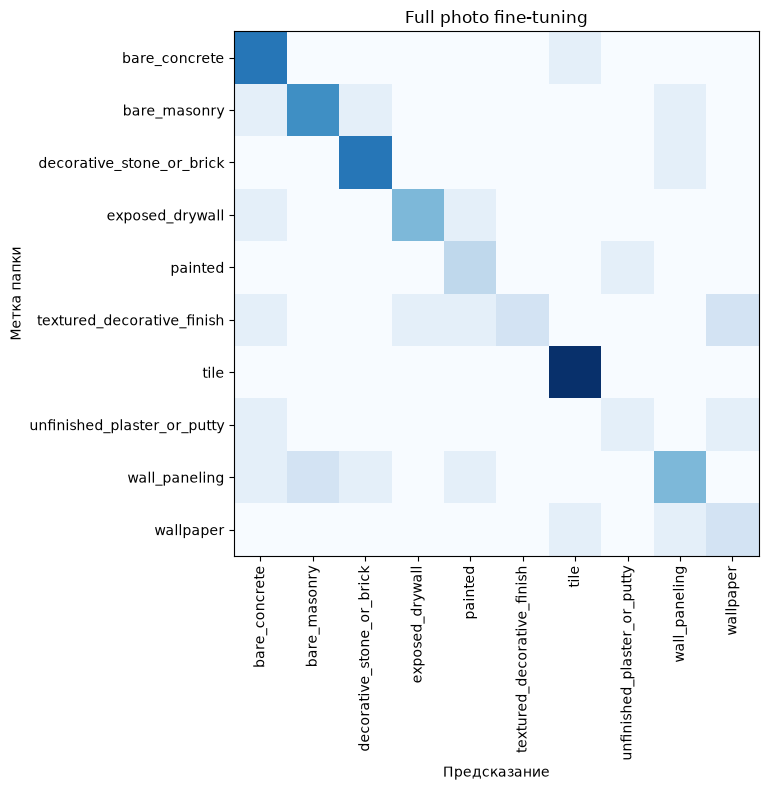

Результаты: /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/wall_training/full_photo_experiments/full_baseline_finetuned


In [26]:
full_ft_net.eval()
ft_truth,ft_predicted = [],[]
with torch.no_grad():
    for images,labels in ft_loaders['test']:
        ft_predicted.extend(full_ft_net(images.to(experiment_device)).argmax(1).cpu().tolist())
        ft_truth.extend(labels.tolist())
ft_report = classification_report(ft_truth,ft_predicted,labels=list(range(len(comparison_classes))),target_names=comparison_classes,zero_division=0)
print(ft_report)
(ft_dir/'classification_report.txt').write_text(ft_report)
ft_predictions = ft_parts['test'].copy()
ft_predictions['predicted_label'] = [comparison_classes[i] for i in ft_predicted]
ft_predictions.to_csv(ft_dir/'test_predictions.csv',index=False)
ft_summary = dict(experiment='full_baseline_finetuned',test_accuracy=accuracy_score(ft_truth,ft_predicted),macro_f1=f1_score(ft_truth,ft_predicted,labels=list(range(len(comparison_classes))),average='macro',zero_division=0),best_val_loss=full_chosen['val_loss'],best_epoch=full_chosen['epoch'],test_size=len(ft_truth),stage=full_chosen['stage'])
(ft_dir/'summary.json').write_text(json.dumps(ft_summary,indent=2))
comparison = [json.loads((base_dir/'summary.json').read_text()),ft_summary]
display(pd.DataFrame(comparison))
ft_matrix = confusion_matrix(ft_truth,ft_predicted,labels=list(range(len(comparison_classes))))
fig,ax = plt.subplots(figsize=(10,8)); ax.imshow(ft_matrix,cmap='Blues')
ax.set_xticks(range(len(comparison_classes)),comparison_classes,rotation=90)
ax.set_yticks(range(len(comparison_classes)),comparison_classes)
ax.set_xlabel('Предсказание'); ax.set_ylabel('Метка папки'); ax.set_title('Full photo fine-tuning')
fig.tight_layout(); fig.savefig(ft_dir/'confusion_matrix.png'); plt.show()
print('Результаты:',ft_dir)


## Этап 5 — Расширенный датасет без изменения старого теста
Выполните ячейку подготовки этапа 3 (FullPhotoDataset и преобразования), затем ячейку определения train_full_photo_experiment. Не запускайте старые ячейки обучения. После этого выполните две ячейки ниже.


In [3]:
import hashlib
# Сохраняем прежние validation/test; новые уникальные фото идут только в train.
old_manifest = pd.read_csv(PROJECT / 'outputs/wall_training/prepared_manifest.csv')
comparison_classes = sorted(old_manifest.label.unique().tolist())
def expanded_pixel_hash(path):
    with Image.open(path) as source:
        image = ImageOps.exif_transpose(source).convert('RGB')
        return hashlib.sha256(f'{image.width}x{image.height}:'.encode() + image.tobytes()).hexdigest()
seen_pixels = set()
for path in old_manifest.path:
    seen_pixels.add(expanded_pixel_hash(path))
old_paths = set(old_manifest.path.map(lambda x: str(Path(x).resolve())))
new_rows = []
for label in comparison_classes:
    folder = PROJECT / 'data/dataset/walls' / label
    for path in sorted(folder.rglob('*')):
        if not path.is_file() or path.suffix.lower() not in {'.jpg','.jpeg','.png','.webp','.bmp','.tif','.tiff'}:
            continue
        if 'duplicates' in path.relative_to(folder).parts or str(path.resolve()) in old_paths:
            continue
        digest = expanded_pixel_hash(path)
        if digest in seen_pixels: continue
        seen_pixels.add(digest)
        new_rows.append(dict(path=str(path.resolve()),label=label,digest=digest,split='train'))
comparison_manifest = pd.concat([old_manifest,pd.DataFrame(new_rows)],ignore_index=True)
comparison_manifest.to_csv(EXPERIMENT_OUT/'expanded_manifest.csv',index=False)
print('Добавлено в train:',len(new_rows))
display(pd.crosstab(comparison_manifest.label,comparison_manifest.split))
print('Старые validation/test сохранены. Изменённые копии и разные снимки одной комнаты автоматически не выявляются.')


Добавлено в train: 2612


split,test,train,val
label,,,
bare_concrete,9,301,10
bare_masonry,10,300,10
decorative_stone_or_brick,9,303,8
exposed_drywall,7,308,5
painted,4,308,8
textured_decorative_finish,7,220,4
tile,11,298,11
unfinished_plaster_or_putty,3,297,5
wall_paneling,10,300,10


Старые validation/test сохранены. Изменённые копии и разные снимки одной комнаты автоматически не выявляются.


In [ ]:
expanded_summary = train_full_photo_experiment('full_expanded_baseline', full_baseline_transform)
previous = json.loads((EXPERIMENT_OUT / 'full_baseline/summary.json').read_text())
display(pd.DataFrame([previous, expanded_summary]))
